### Data Dependencies

In [82]:
library(rsample)     # data splitting 
library(dplyr)       # data wrangling
library(rpart)       # performing regression trees
library(rpart.plot)  # plotting regression trees
library(ipred)       # bagging
library(caret)       # bagging
library(smotefamily) # smote
library(janitor)     # data cleaning
library(tidyverse) 
library(randomForest)
library(xgboost)

### Cleaning Data 

In [87]:
set.seed(100) # Set seed

# Load & Clean Column Names
merged <- read_csv("data/merged_data.csv", show_col_types = FALSE) |> 
  clean_names()

# Train/test split 

strata <- ifelse(merged$outbreak > 0, "nonzero", "zero") 
index <- createDataPartition(strata , p = 0.75, list = FALSE)
train <- merged[index, ]
test  <- merged[-index, ]

# Drop county and NA columns 
train <- train[, colSums(is.na(train)) == 0]
train <- train[, !names(train) %in% c("county")]

# Ensure all columns are numeric 
non_num <- names(train)[!sapply(train, is.numeric)]
if (length(non_num) > 0) {
  train[non_num] <- lapply(train[non_num], as.numeric)
}

# Mirror same cleaning on test set 
test <- test[, names(test) %in% c(names(train), "outbreak")]

non_num_test <- names(test)[!sapply(test, is.numeric) & names(test) != "outbreak"]
if (length(non_num_test) > 0) {
  test[non_num_test] <- lapply(test[non_num_test], as.numeric)
}

test <- test |>
  mutate(across(
    .cols = -outbreak,
    .fns  = ~ifelse(is.na(.), train_medians[cur_column()], .)
  ))

test$outbreak <- as.numeric(test$outbreak)

stopifnot(sum(is.na(test)) == 0)

cat("Train rows:", nrow(train), "| Cols:", ncol(train), "\n")
cat("Test rows:",  nrow(test),  "| Cols:", ncol(test),  "\n")

# Export to csv
write_csv(train, "data/created/train_clean.csv")
write_csv(test,  "data/created/test_clean.csv")

Train rows: 191 | Cols: 220 
Test rows: 63 | Cols: 220 


### SMOGN (IN PYTHON RUN DIFFERENT KERNEL)

In [1]:
import numpy as np
import pandas as pd
import smogn

# Load cleaned train data from R 
train = pd.read_csv("data/created/train_clean.csv")
randomseed = 100

# Apply SMOGN with manual relevance control points 
# rel_ctrl_pts_rg format: [[x, y, derivative], ...]
# x = outbreak value, y = relevance (0 = common, 1 = rare)
# Set low outbreak counts as common (0) and high counts as rare (1)

outbreak_min = train["outbreak"].min()
outbreak_max = train["outbreak"].max()
outbreak_mid = train["outbreak"].median()
outbreak_nonzero_min = train[train["outbreak"] > 0]["outbreak"].min()

# Ensure control points are strictly increasing and unique
# rel_ctrl_pts = [
#     [outbreak_min,        0, 0],   # 0 = common
#     [outbreak_nonzero_min, 0.5, 0], # first nonzero = starting to get rare
#     [outbreak_max,        1, 0],   # max = rarest, oversample most
# ]

rel_ctrl_pts = [
    [0,        0, 0],   
    [2,        1, 0]
]

train_balanced = smogn.smoter(
    data            = train,
    y               = "outbreak",
    k               = 5,
    samp_method     = "balance",
    seed            = randomseed,
    rel_thres       = 0.5,
    rel_method      = "manual",
    rel_ctrl_pts_rg = rel_ctrl_pts
)

print("\nOutbreak distribution after SMOGN:")
print(train_balanced["outbreak"].value_counts().sort_index())
print("Train balanced shape:", train_balanced.shape)


# ── 4. Export balanced train set back for R modeling ──────────────────────
train_balanced.to_csv("data/created/train_balanced.csv", index=False)

r_index: 100%|##########| 11/11 [00:00<00:00, 78.35it/s]



Outbreak distribution after SMOGN:
outbreak
0.0      74
1.0      30
2.0       7
3.0       8
5.0       4
6.0       4
7.0       5
8.0       4
9.0       2
11.0      2
12.0      4
14.0      2
19.0      1
26.0      1
28.0      1
36.0      1
47.0      1
52.0      2
59.0      2
60.0      1
63.0      1
85.0      1
208.0     1
414.0     2
415.0     1
Name: count, dtype: int64
Train balanced shape: (162, 220)


### Regular Regression Tree (No optimization)

Regression Tree Accuracy Metrics:
RMSE (Root Mean Squared Error): 36.1275 
MAE  (Mean Absolute Error)    : 12.192 
R-squared                     : -0.3815 


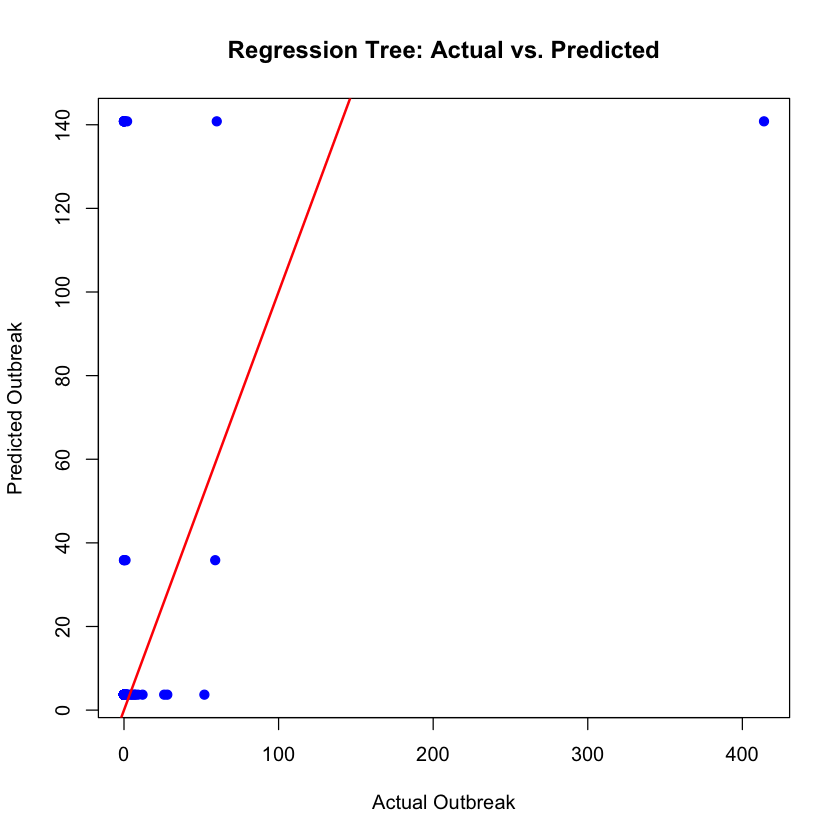

In [74]:
# Read data form CSV
train_balanced <- read_csv("data/created/train_balanced.csv", show_col_types = FALSE) 
test  <- read_csv("data/created/test_clean.csv", show_col_types = FALSE) 

# Train model 
dtree_model <- rpart(outbreak ~ ., data = train_balanced, method = "anova")
#rpart.plot(dtree_model)

# Eval Performance
predictions <- predict(dtree_model, newdata = train)
actual_values <- train$outbreak

# Calculate accuracy metrics using base R math
dtree_rmse <- sqrt(mean((actual_values - predictions)^2))
dtree_mae  <- mean(abs(actual_values - predictions))

rss <- sum((actual_values - predictions)^2)
tss <- sum((actual_values - mean(actual_values))^2)
dtree_r2 <- 1 - (rss / tss)

# Print results to the console
cat("Regression Tree Accuracy Metrics:\n")
cat("RMSE (Root Mean Squared Error):", round(dtree_rmse, 4), "\n")
cat("MAE  (Mean Absolute Error)    :", round(dtree_mae, 4), "\n")
cat("R-squared                     :", round(dtree_r2, 4), "\n")

# Visualize predictions vs actuals
plot(actual_values, predictions, 
     main = "Regression Tree: Actual vs. Predicted", 
     xlab = "Actual Outbreak", ylab = "Predicted Outbreak", 
     pch = 19, col = "blue")
abline(0, 1, col = "red", lwd = 2) # Perfect prediction reference line


### Random Forest (No optimization)

Regression Tree Accuracy Metrics:
RMSE (Root Mean Squared Error): 12.6543 
MAE  (Mean Absolute Error)   : 5.155 
R-squared                    : 0.8305 


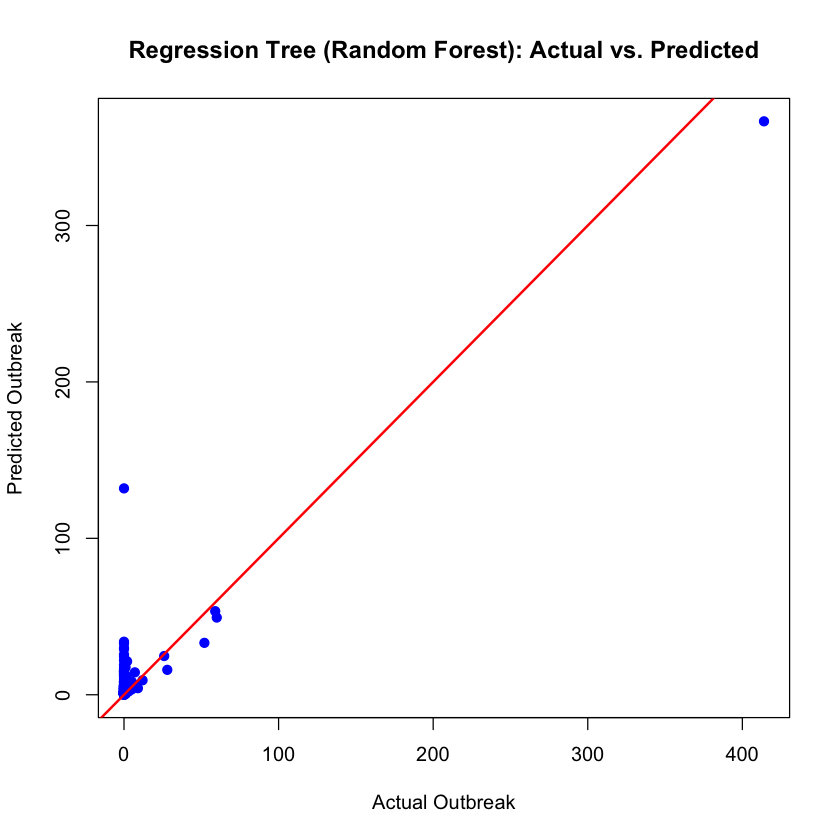

In [29]:
# Train Model
rforest_model <- randomForest(outbreak ~ ., data = train_balanced, ntree = 500, importance = TRUE)

predictions <- predict(rforest_model, newdata = train)
actual_values <- train$outbreak

# Calculate accuracy metrics using base R math
rforest_rmse <- sqrt(mean((actual_values - predictions)^2))
rforest_mae  <- mean(abs(actual_values - predictions))

rss <- sum((actual_values - predictions)^2)
tss <- sum((actual_values - mean(actual_values))^2)
rforest_r2 <- 1 - (rss / tss)

# Print results to the console
cat("Regression Tree Accuracy Metrics:\n")
cat("RMSE (Root Mean Squared Error):", round(rforest_rmse, 4), "\n")
cat("MAE  (Mean Absolute Error)   :", round(rforest_mae, 4), "\n")
cat("R-squared                    :", round(rforest_r2, 4), "\n")

#Visualize predictions vs actuals
plot(actual_values, predictions, 
     main = "Regression Tree (Random Forest): Actual vs. Predicted", 
     xlab = "Actual Outbreak", ylab = "Predicted Outbreak", 
     pch = 19, col = "blue")
abline(0, 1, col = "red", lwd = 2) # Perfect prediction reference line

### Boosted Tree (No optimization)

In [30]:
# 1. Prepare data
X_train <- as.matrix(train_balanced[, names(train_balanced) != "outbreak"])
y_train <- as.numeric(as.character(train_balanced$outbreak))
dtrain <- xgb.DMatrix(data = X_train, label = y_train)

# Prepare the original data for prediction
# Note: ogtrain should be a DMatrix so xgboost can read it
X_og <- as.matrix(train[, names(train) != "outbreak"])
ogtrain <- xgb.DMatrix(data = X_og) 

# 2. Train the model
boost_model <- xgb.train(
  params = list(
    objective = "reg:squarederror",
    max_depth = 3,
    eta = 0.1
  ),
  data = dtrain,
  nrounds = 500
)

# 3. Predict on the ORIGINAL training set
predictions <- predict(boost_model, ogtrain) # Use dogtrain, not dtrain
actual_values <- as.numeric(as.character(train$outbreak)) # Pull from original 'train' dataframe

# 4. Calculate metrics (dimensions now match)
boost_rmse <- sqrt(mean((actual_values - predictions)^2))
boost_mae <- mean(abs(actual_values - predictions))

rss <- sum((actual_values - predictions)^2)
tss <- sum((actual_values - mean(actual_values))^2)
boost_r2 <- 1 - (rss / tss)

# Print results
cat("Regression Tree Accuracy Metrics (Original Train):\n")
cat("RMSE:", round(boost_rmse, 4), "\n")
cat("MAE :", round(boost_mae, 4), "\n")
cat("R-squared :", round(boost_r2, 4), "\n")

# #Visualize predictions vs actuals
# plot(actual_values, predictions, 
#      main = "Regression Tree (Boosted): Actual vs. Predicted", 
#      xlab = "Actual Outbreak", ylab = "Predicted Outbreak", 
#      xlim = c(0, 420), ylim = c(0, 420),
#      pch = 19, col = "blue")
# abline(0, 1, col = "red", lwd = 2) # Perfect prediction reference line

Regression Tree Accuracy Metrics (Original Train):
RMSE: 3.3521 
MAE : 1.6942 
R-squared : 0.9881 


# TUNING SECTION

### Setting up all parameters

In [31]:
# classification tree related
maxdepths <- seq(1, 10, by = 1)
# random forest related
mtrys   <- c(seq(2, 50, by=2))
ntrees   <- c(seq(300, 700, by=50))
# XGBoost related
param_grid <- expand.grid( # tuning grid
  max_depth = c(seq(3, 9, by=2)),
  eta = c(0.01,seq(0.05, 0.4, by=0.05))
)

# Folds for cross validation
set.seed(4)

folds <- createFolds(train_balanced$outbreak, k = 10)
folds

$Fold01
 [1]   7  17  22  27  29  48  55  59  88  91  92 113 115 126 135 147 149

$Fold02
 [1]   4   8  25  34  46  49  54  57  60  63 118 127 132 137 143 150

$Fold03
 [1]   5   9  13  18  23  31  50  56  64  66  71  72 103 119 123 138

$Fold04
 [1]   1  14  28  42  47  51  53  84  94  99 106 107 112 116 124 144 146

$Fold05
 [1]   2  12  20  33  36  41  69  83  86  96 136 140 142 145 156 159

$Fold06
 [1]   3   6  10  19  21  43  62  74  77  90 104 105 108 125 141 160

$Fold07
 [1]  52  61  65  67  70  76  79  80  81  82  93  97 134 139 154 157

$Fold08
 [1]  26  30  38  39  44 100 110 111 120 129 148 151 152 153 155

$Fold09
 [1]  15  16  32  35  37  68  75  78  87  98 101 109 114 117 131 133 162

$Fold10
 [1]  11  24  40  45  58  73  85  89  95 102 121 122 128 130 158 161

### Basic Regression Tree Optimization

maxdepth,cp,RMSE,MAE,R2
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,4.190711e-01,45.79473,22.83434,-1.600009
2,1.563041e-02,48.94770,20.26920,-2.682386
3,1.563041e-02,46.05073,18.95002,-2.646656
4,1.563041e-02,46.11274,18.54555,-2.806645
5,1.563041e-02,49.12566,19.72355,-2.880303
6,1.563041e-02,52.29150,21.52902,-2.673140
7,6.483599e-06,52.98285,21.86257,-3.072251
8,1.319443e-05,46.44989,19.11618,-2.972434
9,1.563041e-02,46.05353,19.16802,-2.638437


  maxdepth        cp     RMSE      MAE        R2
1        1 0.4190711 45.79473 22.83434 -1.600009


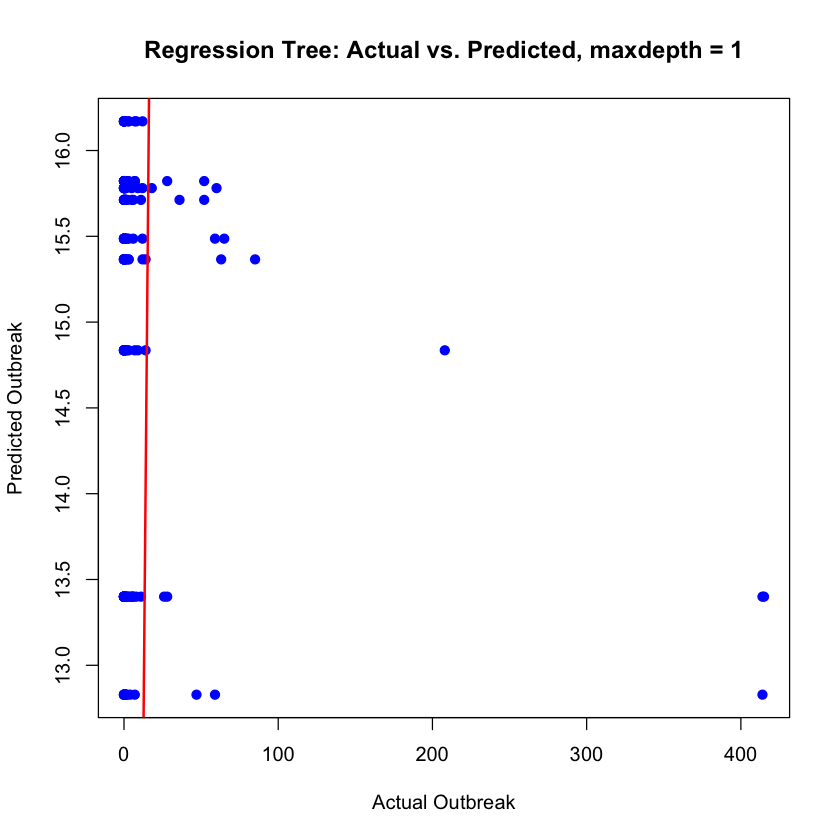

In [32]:
set.seed(100)
results <- data.frame()
pred_plot_data <- list()

for(i in maxdepths){
  fold_rmse <- c()
  fold_mae  <- c()
  fold_r2   <- c()
  depth_predictions <- data.frame()

  for(fold in folds){
    fold_train <- train_balanced[-fold, ]
    fold_test  <- train_balanced[fold, ]

    mod <- rpart(outbreak ~ .,
                 data    = fold_train,
                 method  = "anova",
                 #weights = ceiling(fold_train$population),
                 control = rpart.control(maxdepth = i, cp = -1))

    cp_table <- mod$cptable
    opt_cp   <- as.numeric(cp_table[which.min(cp_table[, "xerror"]), "CP"])[1]
    pruned   <- prune(mod, cp = opt_cp)

    predictions   <- predict(pruned, newdata = fold_test)
    actual_values <- fold_test$outbreak

    depth_predictions <- rbind(depth_predictions, data.frame(
      actual    = actual_values,
      predicted = predictions
    ))

    fold_rmse <- c(fold_rmse, sqrt(mean((actual_values - predictions)^2)))
    fold_mae  <- c(fold_mae,  mean(abs(actual_values - predictions)))

    rss     <- sum((actual_values - predictions)^2)
    tss     <- sum((actual_values - mean(actual_values))^2)
    fold_r2 <- c(fold_r2, if(tss == 0) NA else 1 - (rss / tss))
  }

  pred_plot_data[[as.character(i)]] <- depth_predictions

  results <- rbind(results, data.frame(
    maxdepth      = i,
    cp            = opt_cp,
    RMSE          = mean(fold_rmse, na.rm = TRUE),
    MAE           = mean(fold_mae,  na.rm = TRUE),
    R2            = mean(fold_r2,   na.rm = TRUE)
  ))
}

results
best_clas <- results[which.max(results$R2), ]
print(best_clas)

best_depth     <- best_clas$maxdepth[1]
best_plot_data <- pred_plot_data[[as.character(best_depth)]]

plot(best_plot_data$actual, best_plot_data$predicted,
     main = paste("Regression Tree: Actual vs. Predicted, maxdepth =", best_depth),
     xlab = "Actual Outbreak",
     ylab = "Predicted Outbreak",
     pch  = 19,
     col  = "blue")

abline(0, 1, col = "red", lwd = 2)

### Random Forest Optimization

  mtry     RMSE      MAE        R2
9   45 26.51014 13.08836 -0.653559


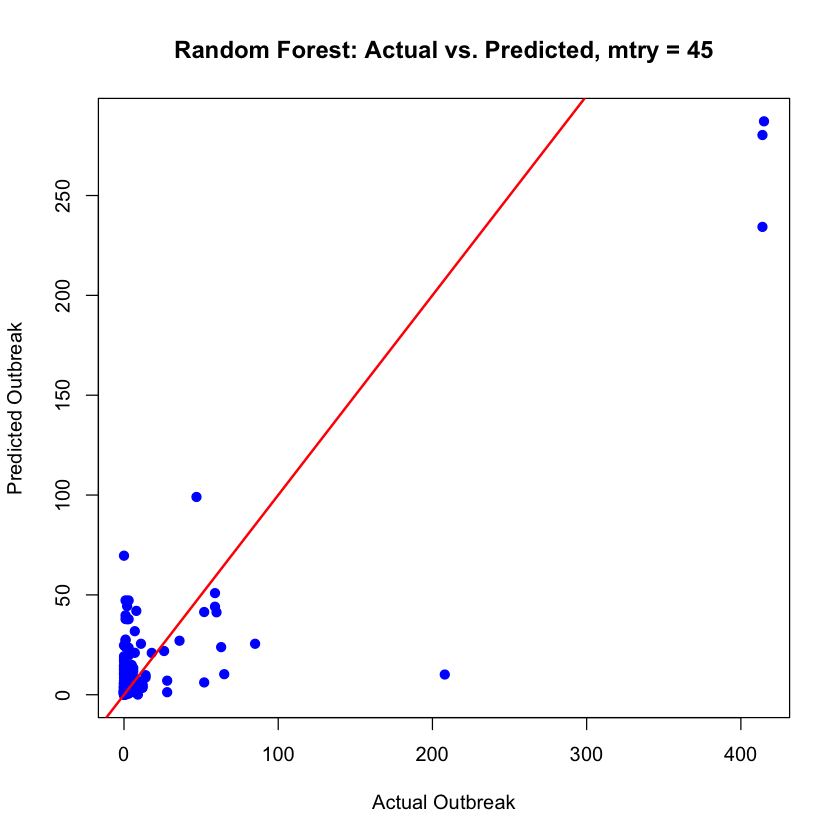

In [33]:
results_rf <- data.frame()
pred_plot_data_rf <- list()

set.seed(100)
for(m in mtrys){
  fold_rmse <- c()
  fold_mae  <- c()
  fold_r2   <- c()
  mtry_predictions <- data.frame()

  for(fold in folds){
    fold_train <- train_balanced[-fold, ]
    fold_test  <- train_balanced[fold, ]

    rf <- randomForest(outbreak ~ .,
                       data       = fold_train,
                       mtry       = m,
                       ntree      = 500,
                       importance = TRUE)

    predictions   <- predict(rf, newdata = fold_test)
    actual_values <- fold_test$outbreak

    mtry_predictions <- rbind(mtry_predictions, data.frame(
      actual = actual_values,
      predicted = predictions
    ))

    fold_rmse <- c(fold_rmse, sqrt(mean((actual_values - predictions)^2)))
    fold_mae  <- c(fold_mae, mean(abs(actual_values - predictions)))

    rss     <- sum((actual_values - predictions)^2)
    tss     <- sum((actual_values - mean(actual_values))^2)
    fold_r2 <- c(fold_r2, 1 - (rss / tss))
  }

  pred_plot_data_rf[[as.character(m)]] <- mtry_predictions

  results_rf <- rbind(results_rf, data.frame(
    mtry = m,
    RMSE = mean(fold_rmse, na.rm = TRUE),
    MAE  = mean(fold_mae,  na.rm = TRUE),
    R2   = mean(fold_r2,   na.rm = TRUE)
  ))
}

best_rf <- results_rf[which.max(results_rf$R2), ]
print(best_rf)

best_mtry <- best_rf$mtry[1]
best_plot_data_rf <- pred_plot_data_rf[[as.character(best_mtry)]]

plot(best_plot_data_rf$actual, best_plot_data_rf$predicted,
     main = paste("Random Forest: Actual vs. Predicted, mtry =", best_mtry),
     xlab = "Actual Outbreak",
     ylab = "Predicted Outbreak",
     pch = 19,
     col = "blue")

abline(0, 1, col = "red", lwd = 2)

### XGBoost Optimization

   max_depth  eta     RMSE      MAE        R2
29         3 0.35 23.16618 10.10783 0.1317431


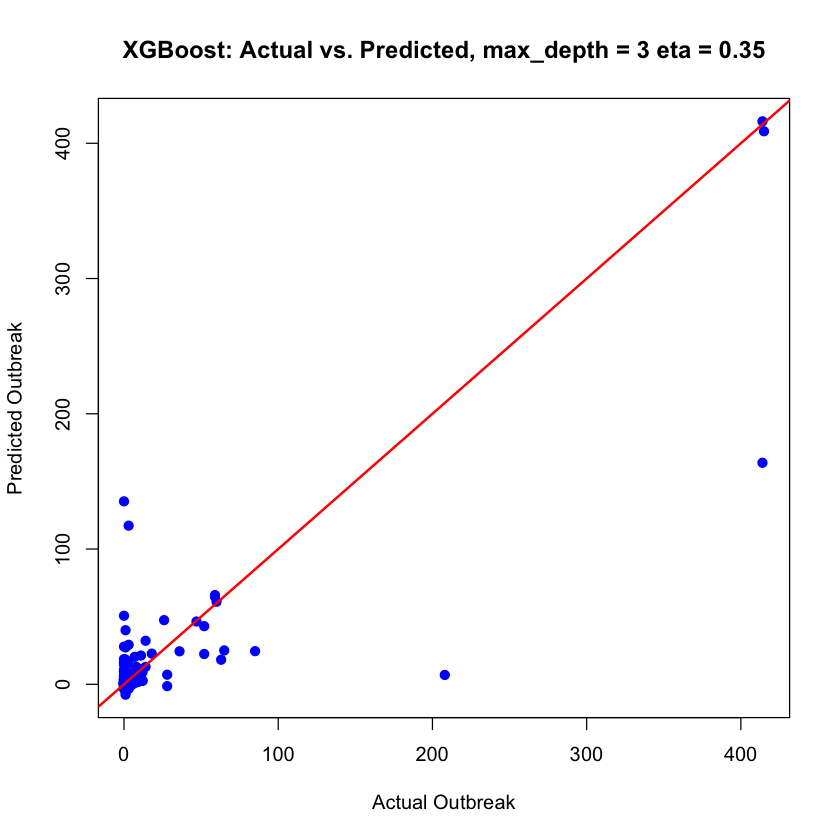

In [34]:
results_xgb <- data.frame()
pred_plot_data_xgb <- list()

set.seed(100)
for(i in 1:nrow(param_grid)){
  fold_rmse <- c()
  fold_mae  <- c()
  fold_r2   <- c()
  xgb_predictions <- data.frame()

  for(fold in folds){
    fold_train <- train_balanced[-fold, ]
    fold_test  <- train_balanced[fold, ]

    X_fold_train <- as.matrix(fold_train[, names(fold_train) != "outbreak"])
    y_fold_train <- as.numeric(as.character(fold_train$outbreak))
    X_fold_test  <- as.matrix(fold_test[, names(fold_test) != "outbreak"])
    y_fold_test  <- as.numeric(as.character(fold_test$outbreak))

    dtrain_fold <- xgb.DMatrix(data = X_fold_train, label = y_fold_train)
    dtest_fold  <- xgb.DMatrix(data = X_fold_test, label = y_fold_test)

    model <- xgb.train(
      params = list(
        objective   = "reg:squarederror",
        eval_metric = "rmse",
        max_depth   = param_grid$max_depth[i],
        eta         = param_grid$eta[i]
      ),
      data    = dtrain_fold,
      nrounds = 500
    )

    predictions   <- predict(model, newdata = dtest_fold)
    actual_values <- fold_test$outbreak

    xgb_predictions <- rbind(xgb_predictions, data.frame(
      actual = actual_values,
      predicted = predictions
    ))

    fold_rmse <- c(fold_rmse, sqrt(mean((actual_values - predictions)^2)))
    fold_mae  <- c(fold_mae, mean(abs(actual_values - predictions)))

    rss     <- sum((actual_values - predictions)^2)
    tss     <- sum((actual_values - mean(actual_values))^2)
    fold_r2 <- c(fold_r2, 1 - (rss / tss))
  }

  combo_name <- paste(param_grid$max_depth[i], param_grid$eta[i], sep = "_")
  pred_plot_data_xgb[[combo_name]] <- xgb_predictions

  results_xgb <- rbind(results_xgb, data.frame(
    max_depth = param_grid$max_depth[i],
    eta       = param_grid$eta[i],
    RMSE      = mean(fold_rmse, na.rm = TRUE),
    MAE       = mean(fold_mae,  na.rm = TRUE),
    R2        = mean(fold_r2,   na.rm = TRUE)
  ))
}

best_xgb <- results_xgb[which.max(results_xgb$R2), ]
print(best_xgb)

best_combo <- paste(best_xgb$max_depth[1], best_xgb$eta[1], sep = "_")
best_plot_data_xgb <- pred_plot_data_xgb[[best_combo]]

plot(best_plot_data_xgb$actual, best_plot_data_xgb$predicted,
     main = paste(
       "XGBoost: Actual vs. Predicted, max_depth =",
       best_xgb$max_depth[1],
       "eta =",
       best_xgb$eta[1]
     ),
     xlab = "Actual Outbreak",
     ylab = "Predicted Outbreak",
     pch = 19,
     col = "blue")

abline(0, 1, col = "red", lwd = 2)

### Parameter tuning for log

In [88]:
# For log transformations
set.seed(100)

# Log transform outbreak
train$outbreak <- log10(train$outbreak + 1)
train_balanced$outbreak  <- log10(train_balanced$outbreak  + 1)

# Recreate folds on transformed target
folds <- createFolds(train$outbreak, k = 10, list = TRUE)

# PARAMETERS TO TUNE: 

# Default values: 
# minsplits: 20, minbuckets: minsplit/3, maxdepth: 30 
# ntrees: 500, mtrys: (# of features)/3, nodesize: 5, maxnode: none 
# learning_rate: 0.3, max_depth: 6, min_child_weight: 1, subsamble: 1, early_stopping: none 

# Base tree: 
minsplits  <- seq(20, 50, by = 5)       # min number of observations that have to be in a node to split
minbuckets <- seq(10, 20, by = 5)       # min number of obervations that have to be in a node 
maxdepths <- seq(10, 30, by = 10)       # max depth of the tree

# Random Forest: 
ntrees <- seq(300, 700, by = 100)       # number of trees to create
mtrys <- seq(10, 60, by = 10)           # number of variables to consider
nodesizes <- seq(5, 20, by = 5)         # min number of obervations that have to be in a node 
maxnodes <- seq(5, 20, by = 5)          # maximum number of nodes in a given tree (minbuckets)

# Xgboost 
eta <- c(0.01, seq(0.05, 0.4, by = 0.05))  # learning rate of each tree
max_depth <- seq(3, 9, by = 3)             # max depth of any tree
min_child_weight <- seq(1, 10, by = 1)     # min nunmber of observations that have to be in a node (minbuckets)
subsample <- seq(0.4, 1, by = 0.1)         # samples a subsample of the total data for each tree
early_stopping <- seq(10, 30, by = 10)     # number of iterations where model stops training if there is marginal imporvement              


### Log regression with tuning for minsplit, minbucket, and cp

In [89]:
set.seed(100)
param_grid_tree <- expand.grid(minsplit  = minsplits,
                               minbucket = minbuckets,
                               maxdepth  = maxdepths)

results_log <- data.frame()

for(i in 1:nrow(param_grid_tree)){
  fold_rmse       <- c()
  fold_mae        <- c()
  fold_r2         <- c()

  for(fold in folds){
    fold_train <- train[-fold, ]
    fold_test  <- train[fold, ]

    mod <- rpart(outbreak ~ .,
                 data    = fold_train,
                 method  = "anova",
                 control = rpart.control(
                   cp        = -1,
                   minsplit  = param_grid_tree$minsplit[i],
                   minbucket = param_grid_tree$minbucket[i],
                   maxdepth = param_grid_tree$maxdepth[i]
                 ))

    cp_table <- mod$cptable
    opt_cp   <- as.numeric(cp_table[which.min(cp_table[, "xerror"]), "CP"])[1]
    pruned   <- prune(mod, cp = opt_cp)

    predictions   <- predict(pruned, newdata = fold_test)
    actual_values <- fold_test$outbreak

    fold_rmse <- c(fold_rmse, sqrt(mean((actual_values - predictions)^2)))
    fold_mae  <- c(fold_mae,  mean(abs(actual_values - predictions)))

    rss     <- sum((actual_values - predictions)^2)
    tss     <- sum((actual_values - mean(actual_values))^2)
    fold_r2 <- c(fold_r2, 1 - (rss / tss))
  }

  results_log <- rbind(results_log, data.frame(
    minsplit  = param_grid_tree$minsplit[i],
    minbucket = param_grid_tree$minbucket[i],
    maxdepth = param_grid_tree$maxdepth[i],
    RMSE      = mean(fold_rmse),
    MAE       = mean(fold_mae),
    R2        = mean(fold_r2)
  ))
}

best_log <- results_log[which.max(results_log$R2), ]
#print(results_log)
print(best_log)


   minsplit minbucket maxdepth      RMSE       MAE         R2
55       45        15       30 0.3085976 0.1801328 -0.6168218


### Random Forest with log and new parameters

In [90]:
set.seed(100)
param_grid_rf <- expand.grid(ntree    = ntrees,
                             mtry     = mtrys,
                             nodesize = nodesizes,
                             maxnodes = maxnodes)

results_rf_log <- data.frame()

for(i in 1:nrow(param_grid_rf)){
  fold_rmse       <- c()
  fold_mae        <- c()
  fold_r2         <- c()

  for(fold in folds){
    fold_train <- train[-fold, ]
    fold_test  <- train[fold, ]

    rf <- randomForest(outbreak ~ .,
                       data     = fold_train,
                       ntree    = param_grid_rf$ntree[i],
                       mtry     = param_grid_rf$mtry[i],
                       nodesize = param_grid_rf$nodesize[i],
                       maxnodes = param_grid_rf$maxnodes[i])

    predictions   <- predict(rf, newdata = fold_test)
    actual_values <- fold_test$outbreak

    fold_rmse <- c(fold_rmse, sqrt(mean((actual_values - predictions)^2)))
    fold_mae  <- c(fold_mae,  mean(abs(actual_values - predictions)))
    
    rss     <- sum((actual_values - predictions)^2)
    tss     <- sum((actual_values - mean(actual_values))^2)
    fold_r2 <- c(fold_r2, 1 - (rss / tss))
  }

  results_rf_log <- rbind(results_rf_log, data.frame(
    ntree    = param_grid_rf$ntree[i],
    mtry     = param_grid_rf$mtry[i],
    nodesize = param_grid_rf$nodesize[i],
    maxnodes = param_grid_rf$maxnodes[i],
    RMSE     = mean(fold_rmse),
    MAE      = mean(fold_mae),
    R2       = mean(fold_r2)
  ))
}

best_rf_log <- results_rf_log[which.max(results_rf_log$R2), ]
print(best_rf_log)

   ntree mtry nodesize maxnodes      RMSE       MAE         R2
25   700   50        5        5 0.3002771 0.1724733 -0.5256998


### Xgboost with new parameters

In [91]:
set.seed(100)
param_grid_xgb <- expand.grid(
  eta               = eta,
  max_depth         = max_depth,
  min_child_weight  = min_child_weight,
  subsample         = subsample,
  early_stopping_rounds    = early_stopping
)

results_xgb_log <- data.frame()

for (i in 1:nrow(param_grid_xgb)) {
  fold_rmse       <- c()
  fold_mae        <- c()
  fold_r2         <- c()

  for (fold in folds) {
    fold_train <- train[-fold, ]
    fold_test  <- train[fold, ]

    dtrain <- xgb.DMatrix(
      data  = as.matrix(fold_train[, !names(fold_train) %in% "outbreak"]),
      label = fold_train$outbreak
    )
    dtest <- xgb.DMatrix(
      data  = as.matrix(fold_test[, !names(fold_test) %in% "outbreak"]),
      label = fold_test$outbreak
    )

    xgb_model <- xgb.train(
      params = list(
        objective        = "reg:squarederror",
        eta              = param_grid_xgb$eta[i],
        max_depth        = param_grid_xgb$max_depth[i],
        min_child_weight = param_grid_xgb$min_child_weight[i],
        subsample        = param_grid_xgb$subsample[i]
      ),
      data       = dtrain,
      nrounds    = 500,
      evals  = list(eval = dtest, train = dtrain),
      early_stopping_rounds = param_grid_xgb$early_stopping[i],
      verbose    = 0
    )

    predictions   <- predict(xgb_model, newdata = dtest)
    actual_values <- fold_test$outbreak

    fold_rmse <- c(fold_rmse, sqrt(mean((actual_values - predictions)^2)))
    fold_mae  <- c(fold_mae,  mean(abs(actual_values - predictions)))

    rss     <- sum((actual_values - predictions)^2)
    tss     <- sum((actual_values - mean(actual_values))^2)
    fold_r2 <- c(fold_r2, 1 - (rss / tss))
  }

  results_xgb_log <- rbind(results_xgb_log, data.frame(
    eta              = param_grid_xgb$eta[i],
    max_depth        = param_grid_xgb$max_depth[i],
    min_child_weight = param_grid_xgb$min_child_weight[i],
    subsample        = param_grid_xgb$subsample[i],
    early_stopping   = param_grid_xgb$early_stopping[i],
    RMSE             = mean(fold_rmse),
    MAE              = mean(fold_mae),
    R2               = mean(fold_r2)
  ))
}

best_xgb_log <- results_xgb_log[which.max(results_xgb_log$R2), ]
print(best_xgb_log)

In [ ]:
fold_r2

sci_hub

[1]  -1.31709537 -19.01068237   0.13178910   0.03435712  -4.81050124
 [6] -26.77005913  -3.03328560  -0.00630637  -0.95373460  -0.03937645

XGBoost Regression Accuracy Metrics:
RMSE (Root Mean Squared Error): 6e-04 
MAE  (Mean Absolute Error)    : 4e-04 
R-squared                     : 1 


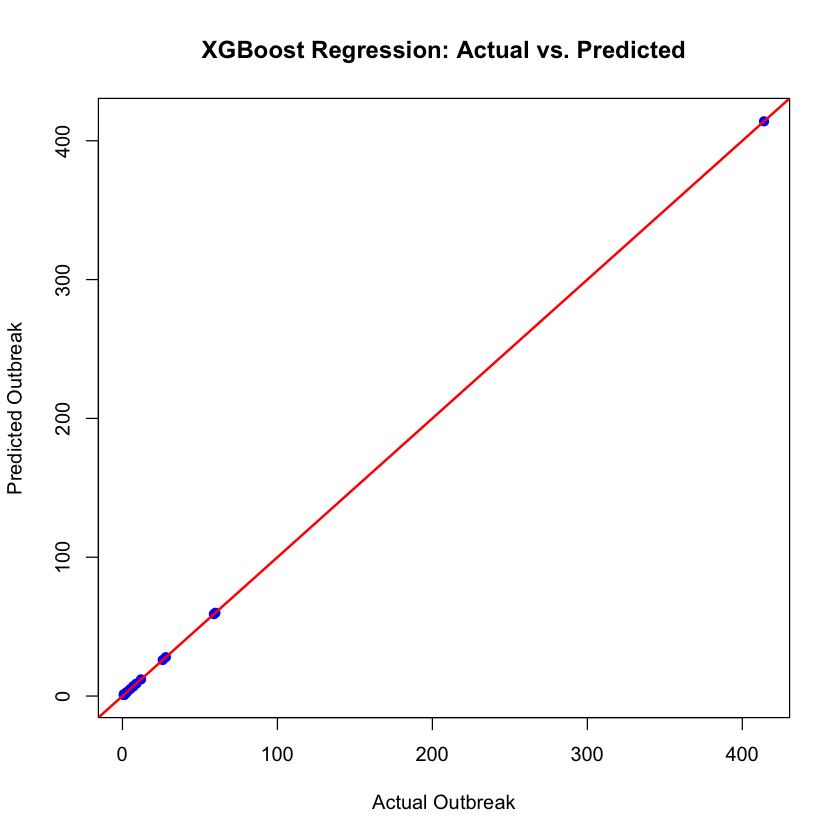

In [ ]:
set.seed(100)
only_outbreak <- train[train$outbreak > 0, ]

index <- createDataPartition(only_outbreak$outbreak, p = 0.75, list = FALSE)

train_outbreak <- only_outbreak[index, ]
test_outbreak  <- only_outbreak[-index, ]

# Feature matrices as plain matrix, no xgb.DMatrix needed
train_x <- as.matrix(train_outbreak[, !names(train_outbreak) %in% "outbreak"])
test_x  <- as.matrix(test_outbreak[,  !names(test_outbreak)  %in% "outbreak"])

# Train Model
xgb_model <- xgboost(
  x             = train_x,
  y             = train_outbreak$outbreak,
  nrounds       = 500,
  objective     = "reg:squarederror",
  learning_rate = 0.1,
  max_depth     = 6,
  verbosity     = 0
)

# Predict - pass plain matrix directly
predictions   <- predict(xgb_model, newdata = train_x)
actual_values <- train_outbreak$outbreak

# Calculate accuracy metrics
xgb_rmse <- sqrt(mean((actual_values - predictions)^2))
xgb_mae  <- mean(abs(actual_values - predictions))

rss <- sum((actual_values - predictions)^2)
tss <- sum((actual_values - mean(actual_values))^2)
xgb_r2 <- 1 - (rss / tss)

# Print results
cat("XGBoost Regression Accuracy Metrics:\n")
cat("RMSE (Root Mean Squared Error):", round(xgb_rmse, 4), "\n")
cat("MAE  (Mean Absolute Error)    :", round(xgb_mae, 4), "\n")
cat("R-squared                     :", round(xgb_r2, 4), "\n")

# Visualize predictions vs actuals
plot(actual_values, predictions,
     main = "XGBoost Regression: Actual vs. Predicted",
     xlab = "Actual Outbreak", ylab = "Predicted Outbreak",
     pch  = 19, col = "blue")
abline(0, 1, col = "red", lwd = 2)